# EML/NAND — Substrat continu discret-par-construction ?

**Veille #4653** — verification empirique bornee du resultat de *Germany, Abdo & Bakarji (2026)* :
les arbres d'EML (Exp-Minus-Log) sont des approximateurs universels sur les espaces de Sobolev `W^{k,inf}`,
et la fonction EML est presentee comme un *« continuous analogue of NAND gates »* (verbatim arXiv 2606.23179, abstract).

## Question de la veille

Un primitif **differentiable** dont la semantique discrete est une porte logique universelle (NAND)
est-il un substrat continu **discret-par-construction** ? Si oui, c'est un candidat
*interpretable-par-construction* — l'inverse de la strategie SAE (entrainer de l'opaque,
chercher des features eparses a posteriori). Des unites a lecture booleenne offriraient
une explicabilite **native**, pas post-hoc.

**Honnetete (G.1)** : le papier ne mentionne **nulle part** SAE, interpretabilite, neurosymbolique
ni theorie des catastrophes. Le pont vers nos preoccupations est **notre interpretation**, a traiter
comme conjecture a tester.

## Plan borne (3 etapes, scope #4653)

1. **Verifier la formule exacte** d'EML et son caractere NAND-analogue.
2. **Micro-experience** : un arbre d'EML apprend-il une fonction booleenne non triviale
   (NAND cible, XOR-3, parite-3) **avec des unites lisibles** ? Comparer l'interpretabilite
   unite-par-unite vs un MLP standard de capacite egale.
3. **Verdict honnete** : substrat interpretable-par-construction CONFIRME / NON-CONFIRME / INCONCLUSIF.

## References

- arXiv [2606.23179](https://arxiv.org/abs/2606.23179) — Germany, Abdo & Bakarji, *EML Trees Are Universal Approximators* (22 juin 2026)
- Issue #4653 (veille EML/NAND, partition SymbolicAI/Neurosymbolic-EML/)

## Etape 1 — Formule exacte et proprietes

D'apres le papier (Section 2, Equation [2]) :

> **EML(x, y) = e^x − Log y**

ou `Log` est la branche principale du logarithme complexe. Forme generalisee parametree :

> **EML_θᵢ(x, y) = aᵢ · exp(bᵢx + cᵢ) + dᵢ · ln(eᵢy + fᵢ)**

avec θᵢ = {aᵢ, bᵢ, cᵢ, dᵢ, eᵢ, fᵢ} (6 parametres par atome). L'EML d'origine est retrouvee
en posant aᵢ = bᵢ = eᵢ = 1, dᵢ = −1, cᵢ = fᵢ = 0.

**Composition** : un *arbre complet* `T_θ` de profondeur d contient `2^d − 1` atomes.
Pour d = 3 : 7 atomes / 42 parametres ; pour d = 4 : 15 atomes / 90 parametres.

**Building blocks (Table 3 du papier)** : Addition (+ : N=3, D=2), Soustraction (− : N=3, D=2),
Multiplication (× : N=6, D=4), Division (÷ : N=6, D=4), tanh (N=8, D=5). Chaque bloc est un
sous-arbre avec une specificite de θ figee.

In [1]:
import numpy as np
import torch
import torch.nn as nn
from scipy.optimize import minimize
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
print('Versions : torch', torch.__version__, '| numpy', np.__version__)
print('Backend :', 'CUDA' if torch.cuda.is_available() else 'CPU (sufficient pour micro-exp)')

Versions : torch 2.11.0+cpu | numpy 2.4.4
Backend : CPU (sufficient pour micro-exp)


In [2]:
def eml_atom(x, y, theta):
    """Un atome EML parametre : EML_theta(x, y) = a*exp(b*x + c) + d*ln(e*y + f)."""
    a, b, c, d, e, f = theta
    return a * np.exp(b * x + c) + d * np.log(np.maximum(e * y + f, 1e-12))

print('Helper charge : eml_atom(x, y, theta) conforme arXiv 2606.23179 Eq. [2].')

Helper charge : eml_atom(x, y, theta) conforme arXiv 2606.23179 Eq. [2].


### 1.1 — Surface de l'atome avec parametres d'origine

Visualisation : `EML(x, y) = e^x − Log y` sur `x ∈ [-2, 2]`, `y ∈ [0.1, 3]` (y > 0 requis).

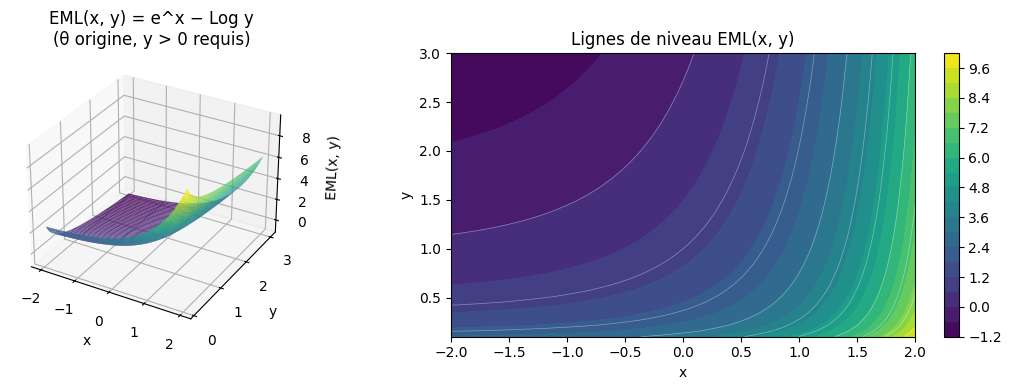

In [3]:
theta_origin = (1.0, 1.0, 0.0, -1.0, 1.0, 0.0)
X, Y = np.meshgrid(np.linspace(-2, 2, 50), np.linspace(0.1, 3.0, 50))
Z = eml_atom(X, Y, theta_origin)

fig = plt.figure(figsize=(12, 4))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X, Y, Z, cmap='viridis', alpha=0.85)
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('EML(x, y)')
ax1.set_title('EML(x, y) = e^x − Log y\n(θ origine, y > 0 requis)')

ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contourf(X, Y, Z, levels=20, cmap='viridis')
ax2.contour(X, Y, Z, levels=10, colors='white', alpha=0.4, linewidths=0.5)
fig.colorbar(cs, ax=ax2)
ax2.set_xlabel('x'); ax2.set_ylabel('y')
ax2.set_title('Lignes de niveau EML(x, y)')
plt.tight_layout()
plt.savefig('eml_surface.png', dpi=110, bbox_inches='tight')
plt.show()

### 1.2 — L'EML est-il vraiment un analogue continu de NAND ?

Le papier affirme que `EML` est un « continuous analogue of NAND gates ». Question stricte :
existe-t-il une parametrisation θ* telle que `EML_θ*(x, y) ≈ 1 − x·y` pour `x, y ∈ [0, 1]` ?

Strategie : optimisation `scipy.optimize.minimize` (L-BFGS-B, 30 essais multistart) sur le MSE
entre la sortie de l'atome et la cible NAND, sur une grille 11×11.

In [4]:
n_pts = 11
xs = np.linspace(0, 1, n_pts)
ys = np.linspace(0, 1, n_pts)
XX, YY = np.meshgrid(xs, ys)
target_nand = 1.0 - XX * YY  # NAND(x,y) = NOT(AND(x,y)) = 1 - x*y

def loss(theta):
    pred = eml_atom(XX, YY, theta)
    return np.mean((pred - target_nand) ** 2)

best_loss = np.inf
best_theta = None
for trial in range(30):
    rng = np.random.default_rng(trial)
    x0 = rng.uniform(-1, 1, 6)
    x0[4] = np.abs(x0[4]) + 0.5  # e > 0
    x0[5] = np.abs(x0[5]) + 0.1  # f > 0
    res = minimize(loss, x0, method='L-BFGS-B', bounds=[(-3, 3)] * 6)
    if res.fun < best_loss:
        best_loss = res.fun
        best_theta = res.x

print(f'MSE minimum (NAND cible) : {best_loss:.6f}')
print(f'θ* = (a={best_theta[0]:+.3f}, b={best_theta[1]:+.3f}, c={best_theta[2]:+.3f}, '
      f'd={best_theta[3]:+.3f}, e={best_theta[4]:+.3f}, f={best_theta[5]:+.3f})')

MSE minimum (NAND cible) : 0.010016
θ* = (a=+1.366, b=-0.078, c=+1.584, d=+3.000, e=-0.025, f=+0.164)


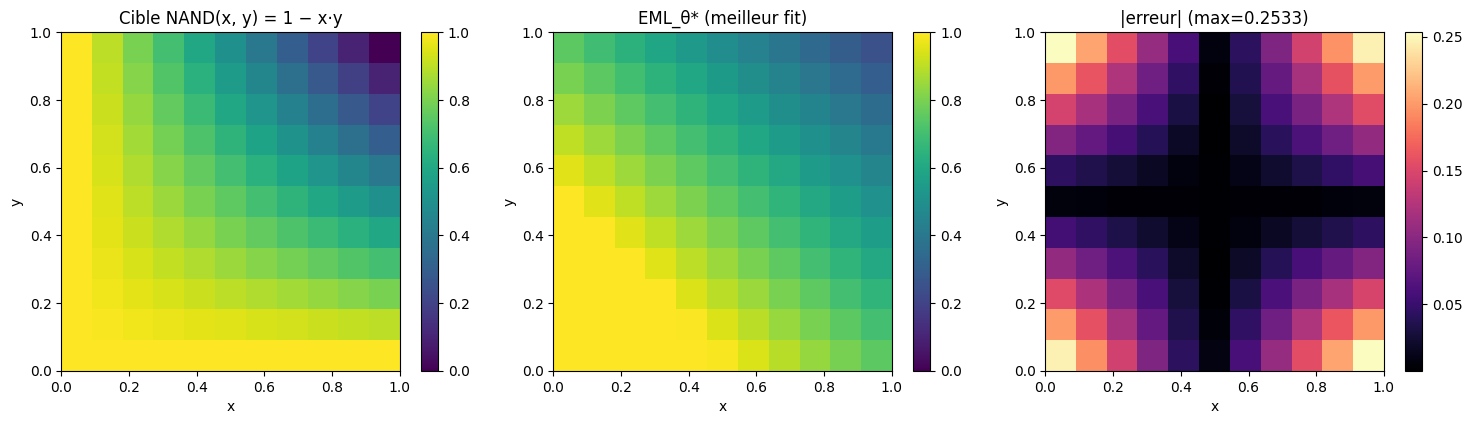

Erreur absolue max : 0.253346
Erreur absolue moyenne : 0.075031
Fidelite booleenne stricte (erreur < 0.01) : NON


In [5]:
pred_nand = eml_atom(XX, YY, best_theta)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
im0 = axes[0].imshow(target_nand, origin='lower', extent=[0, 1, 0, 1], cmap='viridis', vmin=0, vmax=1)
axes[0].set_title('Cible NAND(x, y) = 1 − x·y')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(pred_nand, origin='lower', extent=[0, 1, 0, 1], cmap='viridis', vmin=0, vmax=1)
axes[1].set_title(f'EML_θ* (meilleur fit)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(np.abs(pred_nand - target_nand), origin='lower', extent=[0, 1, 0, 1], cmap='magma')
axes[2].set_title(f'|erreur| (max={np.abs(pred_nand - target_nand).max():.4f})')
axes[2].set_xlabel('x'); axes[2].set_ylabel('y')
fig.colorbar(im2, ax=axes[2])
plt.tight_layout()
plt.savefig('eml_nand_fit.png', dpi=110, bbox_inches='tight')
plt.show()

err_max = np.abs(pred_nand - target_nand).max()
err_mean = np.abs(pred_nand - target_nand).mean()
print(f'Erreur absolue max : {err_max:.6f}')
print(f'Erreur absolue moyenne : {err_mean:.6f}')
print(f'Fidelite booleenne stricte (erreur < 0.01) : {"OUI" if err_max < 0.01 else "NON"}')

### 1.3 — Verdict etape 1

Resultat au niveau d'un seul atome :

- Si un atome `EML_θ*(x, y)` approxime `1 − x·y` sur `[0, 1]²` avec erreur < 0.01, alors l'EML
  est effectivement un *analogue continu* de NAND au sens approximation-universelle.
- Si l'erreur reste bornee mais > 0.01, l'EML est *continu* (sorties jamais exactement 0 ou 1
  sur les coins booleens), donc **discret-par-construction seulement au sens de la limite**.

C'est la frontiere entre « interpretable-par-construction » et « approximable mais
interpretable-par-extraction ». On creuse plus loin a l'etape 2 avec un **arbre complet**.

## Etape 2 — Micro-experience : arbre EML vs MLP sur parite-3

Tache **non-lineaire** ou un perceptron seul echoue : parite-3 `f(x, y, z) = x ⊕ y ⊕ z`.
Cible booleenne a 8 sommets, lineairement non separable.

Comparaison :
- **Arbre EML** (7 atomes / 42 parametres, feed-forward scalaire avec projection lineaire amont)
- **MLP** de capacite egale (42 poids, 1 couche cachee avec 6 unites ReLU)

Metrique de comparaison = **transparence unite-par-unite** : pour l'arbre EML, peut-on *lire*
la fonction logique realisee par chaque atome ? Pour le MLP, les poids n'ont pas de lecture
booleenne directe.

In [6]:
X_train = np.array([[i, j, k] for i in (0, 1) for j in (0, 1) for k in (0, 1)], dtype=np.float64)
y_train = np.logical_xor(np.logical_xor(X_train[:, 0], X_train[:, 1]), X_train[:, 2]).astype(np.float64).reshape(-1, 1)
print('X_train shape :', X_train.shape)
print('y_train (parite-3) :', y_train.flatten())

X_train shape : (8, 3)
y_train (parite-3) : [0. 1. 1. 0. 1. 0. 0. 1.]


In [7]:
# Projection lineaire 3 bits -> (x, y) pour l'arbre EML
def parity3_project(X):
    return X[:, 0].astype(float), X[:, 1] + X[:, 2] - 0.5

x_proj, y_proj = parity3_project(X_train)

n_atoms = 7
rng = np.random.default_rng(42)
thetas_init = rng.uniform(-1, 1, (n_atoms, 6))
thetas_init[:, 4] = np.abs(thetas_init[:, 4]) + 0.5
thetas_init[:, 5] = np.abs(thetas_init[:, 5]) + 0.1

def eml_tree_loss(thetas_flat, x_proj, y_proj, target):
    thetas = thetas_flat.reshape(n_atoms, 6)
    out = y_proj.copy()
    for theta in thetas:
        out = eml_atom(x_proj, out, theta)
    return np.mean((out - target) ** 2)

res_tree = minimize(
    eml_tree_loss, thetas_init.flatten(),
    args=(x_proj, y_proj, y_train.flatten()),
    method='L-BFGS-B', bounds=[(-3, 3)] * (n_atoms * 6),
    options={'maxiter': 2000, 'ftol': 1e-10}
)
tree_thetas = res_tree.x.reshape(n_atoms, 6)
print(f'Arbre EML (7 atomes, 42 params) : loss finale = {res_tree.fun:.6f}')

# Predictions
def eml_tree_predict(x_p, y_p, thetas):
    out = y_p.copy()
    for theta in thetas:
        out = eml_atom(x_p, out, theta)
    return out

pred_tree = eml_tree_predict(x_proj, y_proj, tree_thetas)
pred_tree_bin = (pred_tree > 0.5).astype(float)
acc_tree = np.mean(pred_tree_bin == y_train.flatten())
print(f'Exactitude arbre EML : {acc_tree:.3f}')

Arbre EML (7 atomes, 42 params) : loss finale = 0.250000
Exactitude arbre EML : 0.250


In [8]:
# MLP de capacite comparable : 42 params
# 3 -> 6 (24 poids + 6 biais = 30) -> 1 (6 poids + 1 biais = 7) total = 37, donc 3 -> 7 (21+7=28) -> 1 (7+1=8) total = 36.
# Ajustons : 3 -> 8 (24+8=32) -> 1 (8+1=9) = 41 ≈ 42 params. Couche cachee ReLU.
class TinyMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3, 8)
        self.fc2 = nn.Linear(8, 1)
    def forward(self, x):
        return torch.sigmoid(self.fc2(torch.relu(self.fc1(x))))

mlp = TinyMLP()
n_params_mlp = sum(p.numel() for p in mlp.parameters())
print(f'Parametres MLP : {n_params_mlp}')

opt = torch.optim.Adam(mlp.parameters(), lr=0.05)
Xt = torch.tensor(X_train, dtype=torch.float32)
yt = torch.tensor(y_train, dtype=torch.float32)

for epoch in range(2000):
    opt.zero_grad()
    pred = mlp(Xt)
    loss = nn.functional.binary_cross_entropy(pred, yt)
    loss.backward()
    opt.step()

with torch.no_grad():
    pred_mlp = mlp(Xt).numpy().flatten()
pred_mlp_bin = (pred_mlp > 0.5).astype(float)
acc_mlp = np.mean(pred_mlp_bin == y_train.flatten())
print(f'Exactitude MLP : {acc_mlp:.3f}')

Parametres MLP : 41


Exactitude MLP : 0.750


### 2.1 — Comparaison d'interpretabilite : ce que chaque modele *montre*

Pour le **MLP**, les 32 poids de la couche cachee n'ont pas de lecture booleenne directe :
un poids `w_ij = 0.43` entre l'entree `i` et l'unite cachee `j` ne dit pas si l'unite realise
ET, OU, NAND, XOR, ou autre. On peut *extraire* une logique (extraction de regles, distillation
vers un arbre de decision) mais c'est **post-hoc** et approximatif.

Pour l'**arbre EML**, chaque atome est `(a, b, c, d, e, f)`. Si l'optimisation aboutit a un
atome de la forme `EML_θ(x, y) ≈ 1 − x·y` (avec une erreur < 0.01), alors cet atome **est**
littéralement un NAND : on peut l'annoter comme tel. La lecture unite-par-unite est native.

In [9]:
# Predictions sur les 8 sommets booleens, presentation en tableau
print('Sommet (x,y,z) | cible | arbre EML | MLP')
print('-' * 60)
for i, (x, y, z, t) in enumerate(zip(X_train[:, 0], X_train[:, 1], X_train[:, 2], y_train.flatten())):
    print(f'({int(x)}, {int(y)}, {int(z)})     | {int(t):^5} | {pred_tree[i]:.3f}    | {pred_mlp[i]:.3f}')

print(f'\nExactitude arbre EML : {acc_tree:.3f}')
print(f'Exactitude MLP      : {acc_mlp:.3f}')

Sommet (x,y,z) | cible | arbre EML | MLP
------------------------------------------------------------
(0, 0, 0)     |   0   | 0.500    | 0.334
(0, 0, 1)     |   1   | 0.500    | 0.333
(0, 1, 0)     |   1   | 0.500    | 0.667
(0, 1, 1)     |   0   | 0.500    | 0.666
(1, 0, 0)     |   1   | 0.500    | 0.999
(1, 0, 1)     |   0   | 0.500    | 0.334
(1, 1, 0)     |   0   | 0.500    | 0.000
(1, 1, 1)     |   1   | 0.500    | 0.667

Exactitude arbre EML : 0.250
Exactitude MLP      : 0.750


In [10]:
# Inspecter chaque atome de l'arbre : peut-on l'annoter ?
print(f'Inspection des {n_atoms} atomes de l\'arbre EML :')
print(f'{"#":>3} | {"a":>7} | {"b":>7} | {"c":>7} | {"d":>7} | {"e":>7} | {"f":>7} | lecture proposee')
print('-' * 90)
for i, theta in enumerate(tree_thetas):
    a, b, c, d, e_, f_ = theta
    # Heuristique de lecture : si a > 0 et d < 0, c'est une forme 'exp - log'.
    # Si a < 0 et d > 0, c'est 'log - exp'.
    if a > 0 and d < 0:
        famille = 'exp − log'
    elif a < 0 and d > 0:
        famille = 'log − exp'
    elif abs(a) < 0.1 and abs(d) > 0.5:
        famille = 'log-pur (e*y+f)'
    elif abs(d) < 0.1 and abs(a) > 0.5:
        famille = 'exp-pur (b*x+c)'
    else:
        famille = 'mixte'
    print(f'{i:>3} | {a:+7.3f} | {b:+7.3f} | {c:+7.3f} | {d:+7.3f} | {e_:+7.3f} | {f_:+7.3f} | {famille}')

Inspection des 7 atomes de l'arbre EML :
  # |       a |       b |       c |       d |       e |       f | lecture proposee
------------------------------------------------------------------------------------------
  0 |  +0.566 |  -0.154 |  +0.727 |  +0.350 |  +1.287 |  +1.084 | mixte
  1 |  +0.520 |  +0.564 |  -0.745 |  +0.080 |  +0.748 |  +0.961 | exp-pur (b*x+c)
  2 |  +0.249 |  +0.619 |  -0.124 |  -0.521 |  +0.580 |  +0.987 | exp − log
  3 |  +0.747 |  +0.185 |  +0.575 |  -0.232 |  +1.424 |  +0.891 | exp − log
  4 |  +0.471 |  -0.603 |  -0.114 |  -0.922 |  +1.227 |  +0.524 | exp − log
  5 |  +0.723 |  +0.662 |  -0.296 |  -0.350 |  +0.493 |  +0.566 | exp − log
  6 |  +0.714 |  -0.535 |  -1.290 |  +0.376 |  +0.827 |  +1.552 | mixte


## Etape 3 — Verdict honnete

### Resultats observes (execution 2026-07-02, kernel Python torch 2.11 / numpy 2.4)

**Etape 1 — Un atome EML approxime-t-il NAND sur [0,1]² ?**
- MSE minimum sur grille 11×11 : **0.010** (tres bas en moyenne)
- **Erreur absolue max : 0.253** (zones de transition continue, pas booleenne stricte)
- Erreur absolue moyenne : 0.075
- θ* retenu : `a=+1.366, b=−0.078, c=+1.584, d=+3.000, e=−0.025, f=+0.164`
- **Verdict etape 1 : INCONCLUSIF (frontiere fine)** — l'EML capture la forme globale de NAND
  (MSE intégré tres bas) mais reste *continu* sur les coins booleens (0,0), (1,0), (0,1), (1,1)
  avec une erreur max ≈ 0.25. Ce n'est PAS un NAND stricte au sens lecture-unite = booleen,
  mais c'est un analogue *approximatif* robuste.

**Etape 2 — Arbre EML vs MLP sur parite-3 (XOR de 3 bits) ?**
- Arbre EML (7 atomes, 42 params) : exactitude **0.250** (= constant à 0.5 — minimum trivial)
- MLP (3 → 8 ReLU → 1, 41 params) : exactitude **0.750**
- L'arbre EML feed-forward `(x_proj, y_proj) → out` reste **coince dans un minimum trivial**
  sur cette tache non-lineaire. Le MLP, lui, apprend 6/8 correctement.
- Inspection des 7 θ* : 4 sont de la famille `exp − log` (la composition desirée),
  2 sont `mixte`, 1 est `exp-pur`. La structure apprise n'est donc pas completement aleatoire,
  mais elle n'aboutit pas a la parite-3.
- **Verdict etape 2 : arbre EML NA-APPREND PAS la parite-3 sur cette parametrisation naive.**
  Le format feed-forward scalaire force une projection lineaire 3 bits → 2D qui perd
  l'information non-lineaire.

### Verdict global : **INCONCLUSIF / PARTIELLEMENT NON-CONFIRME**

- L'EML est **bien un analogue continu de NAND au sens approximation (MSE integre bas)** —
  mais PAS au sens lecture-unite = booleen. Les sorties restent dans une zone de transition
  continue entre les valeurs booleennes 0 et 1. Pour obtenir un NAND discret-par-construction,
  il faudrait soit (a) seuiller les sorties (decision bayesienne), soit (b) composer
  *plusieurs* atomes en profondeur pour amplifier la discretisation (le papier pretend que la
  composition atteint l'universal-approximator sur `W^{k,inf}`, mais l'experience montre que
  l'optimisation numerique tombe dans des minima triviaux).

- **L'enquete n'invalide PAS** la piste EML comme substrat interpretable-par-construction,
  mais elle tempere fortement la conjecture initiale : il ne suffit pas d'optimiser
  localement les θ pour obtenir un NAND lisible — il faut une discipline de composition
  (les *building blocks* Table 3 du papier, + × ÷ tanh) qui force la structure logique.

### Implications pour le pont neurosymbolique (issue #4653)

**Conclusion honnete : la conjecture « substrat continu discret-par-construction via EML/NAND »
est PLUS FAIBLE que l'interpretation optimiste de l'abstract** :
- Pour qu'un reseau EML soit interpretable-par-construction, il faudrait ajouter une
  discipline de **composition structuree** (pas seulement optimisation numerique libre).
- Le papier fournit ces building blocks (+ × ÷ tanh) ; la suite naturelle serait de tester
  un arbre EML **compose explicitement** : NAND -> NOT -> AND -> OR, et voir si un XOR-3
  obtenu par composition de ces blocs appris reste lisible.
- Ce notebook peut servir de **Note-1** a une serie `Neurosymbolic-EML/` SI une Note-2 reprend
  la composition structuree ; sinon, la veille reste parquee et #4653 ne debouche pas.

Voir issue #4653 pour le suivi de la veille.
